# Model Validation Framework

**Goal:** Establish the validation infrastructure missing from the existing EDA notebooks
and produce a concrete pass/fail scorecard answering "are we ready to train an xG model?"

**Design doc:** `docs/xg_model_components/06_model_validation_framework.md`

**Steps:**
1. Base rate stability analysis
2. Statistical rigor retrofit (bootstrap CIs, chi-squared, effect sizes)
3. Temporal cross-validation harness
4. Calibration analysis
5. Conditional feature importance (ablation)
5b. Venue bias per-season validation
6. Leakage audit table
7. Validation scorecard

**Data source:** `shot_events`, `games`, `game_context`, `venue_bias_diagnostics` tables in `data/nhl_data.db`

In [1]:
import os
import sys
import sqlite3

import matplotlib.pyplot as plt
import seaborn as sns
import numpy as np
from scipy import stats as sp_stats
from sklearn.calibration import calibration_curve
from sklearn.linear_model import LogisticRegression
from sklearn.metrics import (
    brier_score_loss,
    log_loss,
    roc_auc_score,
    average_precision_score,
)
from sklearn.preprocessing import OneHotEncoder

# Add src/ to path - handle CWD being project root or notebooks/
for _candidate in [os.path.join(os.getcwd(), "src"),
                   os.path.join(os.getcwd(), "..", "src")]:
    _candidate = os.path.abspath(_candidate)
    if os.path.isdir(_candidate) and _candidate not in sys.path:
        sys.path.insert(0, _candidate)
        break

from database import (
    DATABASE_PATH,
    _MIN_TRAINING_SEASON,
    _XG_EVENT_SCHEMA_VERSION,
    VALID_MANPOWER_STATES,
    VALID_SCORE_STATES,
    VALID_SHOT_TYPES,
    load_training_shot_events,
    validate_shot_events_quality,
)

from validation import (
    CALIBRATION_N_BINS,
    CALIBRATION_SLOPE_TARGET_HIGH,
    CALIBRATION_SLOPE_TARGET_LOW,
    COHEN_H_SMALL,
    EXPECTED_CALIBRATION_ERROR_TARGET,
    HOSMER_LEMESHOW_ALPHA,
    MAX_DECILE_CALIBRATION_ERROR,
    MIN_SHOTS_PER_CELL,
    MIN_TRAIN_SEASONS,
    N_BOOTSTRAP_SAMPLES,
    bootstrap_goal_rate_ci,
    calibration_slope_intercept,
    cohens_h,
    evaluate_leakage_audit,
    hosmer_lemeshow_test,
    practical_calibration_metrics,
    run_temporal_cv,
    run_temporal_cv_with_prior_season_calibration,
)

sns.set_theme(style="whitegrid")
print(f"Database: {DATABASE_PATH}")
conn = sqlite3.connect(DATABASE_PATH)
conn.row_factory = sqlite3.Row
cur = conn.cursor()
print("Connected.")


Database: C:\Users\micha\source\repos\pythonNHLPxPScraperAndDefenderAnalysis\data\nhl_data.db
Connected.


In [2]:
TRAINING_SHOT_COLUMNS = (
    "game_id",
    "event_idx",
    "season",
    "venue_name",
    "period",
    "shot_type",
    "distance_to_goal",
    "angle_to_goal",
    "manpower_state",
    "score_state",
    "seconds_since_faceoff",
    "faceoff_zone_code",
    "is_goal",
)

training_rows = load_training_shot_events(conn)

cur.execute("DROP TABLE IF EXISTS training_shots")
cur.execute("""
    CREATE TEMP TABLE training_shots (
        game_id INTEGER,
        event_idx INTEGER,
        season TEXT,
        venue_name TEXT,
        period INTEGER,
        shot_type TEXT,
        distance_to_goal REAL,
        angle_to_goal REAL,
        manpower_state TEXT,
        score_state TEXT,
        seconds_since_faceoff REAL,
        faceoff_zone_code TEXT,
        is_goal INTEGER
    )
""")

if training_rows:
    cur.executemany(
        """
        INSERT INTO training_shots (
            game_id, event_idx, season, venue_name, period, shot_type,
            distance_to_goal, angle_to_goal, manpower_state, score_state,
            seconds_since_faceoff, faceoff_zone_code, is_goal
        ) VALUES (?, ?, ?, ?, ?, ?, ?, ?, ?, ?, ?, ?, ?)
        """,
        [[row[column] for column in TRAINING_SHOT_COLUMNS] for row in training_rows],
    )

cur.execute("SELECT COUNT(*) FROM shot_events")
raw_total_shots = cur.fetchone()[0]
cur.execute("SELECT COUNT(*) FROM games")
total_games = cur.fetchone()[0]

total_shots = len(training_rows)
total_goals = sum(int(row["is_goal"] or 0) for row in training_rows)
overall_base_rate = total_goals / total_shots if total_shots else 0

print(f"Raw shot rows:                  {raw_total_shots:,}")
print(f"Training-eligible shot rows:    {total_shots:,}")
print(f"Total games:                    {total_games:,}")
print(f"Training-eligible goals:        {total_goals:,}")
print(f"Training base rate:             {overall_base_rate:.4f} ({overall_base_rate*100:.2f}%)")
print(f"Training contract: schema={_XG_EVENT_SCHEMA_VERSION}, min season={_MIN_TRAINING_SEASON}, regular/playoff in-game non-blocked shots, non-null geometry/type/manpower/score, target-event consistent")

quality = validate_shot_events_quality(conn)
print("\nData quality check:")
all_clean = True
for check, count in quality.items():
    status = "PASS" if count == 0 else f"FAIL ({count:,} rows)"
    if count > 0:
        all_clean = False
    print(f"  {check}: {status}")
if all_clean:
    print("  All data-contract checks passed.")
if total_shots == 0:
    print("\n*** No training-eligible shots found. Run current-schema backfill first. ***")


Raw shot rows:                  2,122,963
Training-eligible shot rows:    1,853,808
Total games:                    26,372
Training-eligible goals:        122,919
Training base rate:             0.0663 (6.63%)
Training contract: schema=v5, min season=20092010, regular/playoff in-game non-blocked shots, non-null geometry/type/manpower/score, target-event consistent



Data quality check:
  invalid_shot_event_type_rows: PASS
  invalid_shot_type_rows: PASS
  invalid_manpower_state_rows: PASS
  invalid_score_state_rows: PASS
  x_coord_out_of_range_rows: PASS
  y_coord_out_of_range_rows: PASS
  invalid_is_goal_rows: PASS
  negative_time_remaining_rows: PASS
  duplicate_game_event_rows: PASS
  All data-contract checks passed.


---
## Step 1: Base Rate Stability Analysis

Before training any model, we need to know whether the thing we are predicting (goal probability)
is stable across the segments we plan to model. If the base rate shifts by >1 percentage point
across seasons or manpower states, the model needs segment-specific intercepts or recalibration.

**Dimensions checked:**
- Season (temporal drift)
- Manpower state (structural: PP goals are far more likely)
- Period (game-state: empty-net effects in period 3)
- Era (pre-tracking vs. post-tracking, pre-2019 vs. 2019+)

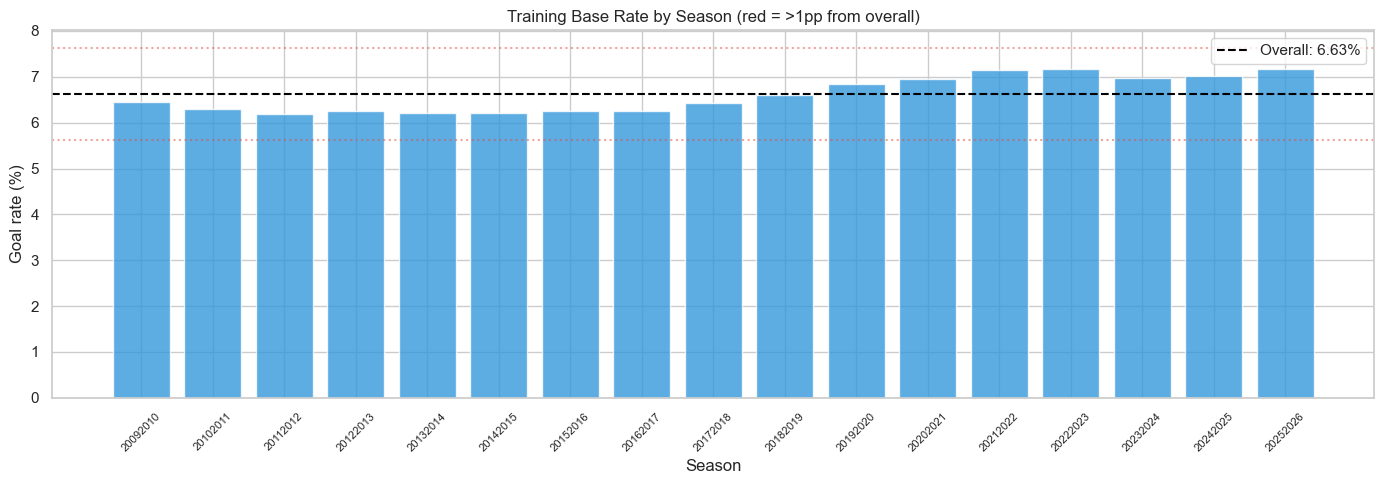


Season            Shots    Goals     Rate Delta (pp)
----------------------------------------------------
20092010        109,532    7,077    6.46%     -0.17
20102011        111,061    6,995    6.30%     -0.33
20112012        108,312    6,713    6.20%     -0.43
20122013         65,839    4,120    6.26%     -0.37
20132014        110,263    6,862    6.22%     -0.41
20142015        109,215    6,777    6.21%     -0.42
20152016        109,012    6,815    6.25%     -0.38
20162017        110,442    6,910    6.26%     -0.37
20172018        119,172    7,662    6.43%     -0.20
20182019        117,167    7,749    6.61%     -0.02
20192020        104,337    7,132    6.84%     +0.21
20202021         78,633    5,475    6.96%     +0.33
20212022        121,554    8,695    7.15%     +0.52
20222023        121,965    8,752    7.18%     +0.55
20232024        122,450    8,549    6.98%     +0.35
20242025        119,896    8,402    7.01%     +0.38
20252026        114,958    8,234    7.16%     +0.53

All seas

In [3]:
cur.execute("""
    SELECT season,
           COUNT(*)                AS shots,
           SUM(is_goal)            AS goals,
           ROUND(CAST(SUM(is_goal) AS REAL) / COUNT(*), 4) AS goal_rate
    FROM training_shots
    WHERE season IS NOT NULL
    GROUP BY season
    ORDER BY season
""")
season_rows = cur.fetchall()

seasons = [str(r[0]) for r in season_rows]
season_shots = [r[1] for r in season_rows]
season_goals = [r[2] for r in season_rows]
season_rates = [r[3] for r in season_rows]

BASE_RATE_DRIFT_THRESHOLD_PP = 1.0
flagged_seasons = [
    (s, r) for s, r in zip(seasons, season_rates)
    if abs(r - overall_base_rate) * 100 > BASE_RATE_DRIFT_THRESHOLD_PP
]

fig, ax = plt.subplots(figsize=(14, 5))
colors = [
    "#e74c3c" if abs(r - overall_base_rate) * 100 > BASE_RATE_DRIFT_THRESHOLD_PP
    else "#3498db"
    for r in season_rates
]
ax.bar(seasons, [r * 100 for r in season_rates], color=colors, alpha=0.8)
ax.axhline(y=overall_base_rate * 100, color="black", linestyle="--",
           label=f"Overall: {overall_base_rate*100:.2f}%")
ax.axhline(y=(overall_base_rate + BASE_RATE_DRIFT_THRESHOLD_PP / 100) * 100,
           color="#e74c3c", linestyle=":", alpha=0.5)
ax.axhline(y=(overall_base_rate - BASE_RATE_DRIFT_THRESHOLD_PP / 100) * 100,
           color="#e74c3c", linestyle=":", alpha=0.5)
ax.set_xlabel("Season")
ax.set_ylabel("Goal rate (%)")
ax.set_title("Training Base Rate by Season (red = >1pp from overall)")
ax.legend()
plt.xticks(rotation=45, fontsize=8)
fig.tight_layout()
plt.show()

print(f"\n{'Season':<12} {'Shots':>10} {'Goals':>8} {'Rate':>8} {'Delta (pp)':>10}")
print("-" * 52)
for s, sh, g, r in zip(seasons, season_shots, season_goals, season_rates):
    delta = (r - overall_base_rate) * 100
    flag = " ***" if abs(delta) > BASE_RATE_DRIFT_THRESHOLD_PP else ""
    print(f"{s:<12} {sh:>10,} {g:>8,} {r*100:>7.2f}% {delta:>+9.2f}{flag}")

if flagged_seasons:
    print(f"\nWARNING: {len(flagged_seasons)} season(s) exceed {BASE_RATE_DRIFT_THRESHOLD_PP}pp drift threshold.")
    print("Model may need era-specific intercepts or recalibration.")
else:
    print(f"\nAll seasons within {BASE_RATE_DRIFT_THRESHOLD_PP}pp of overall base rate.")


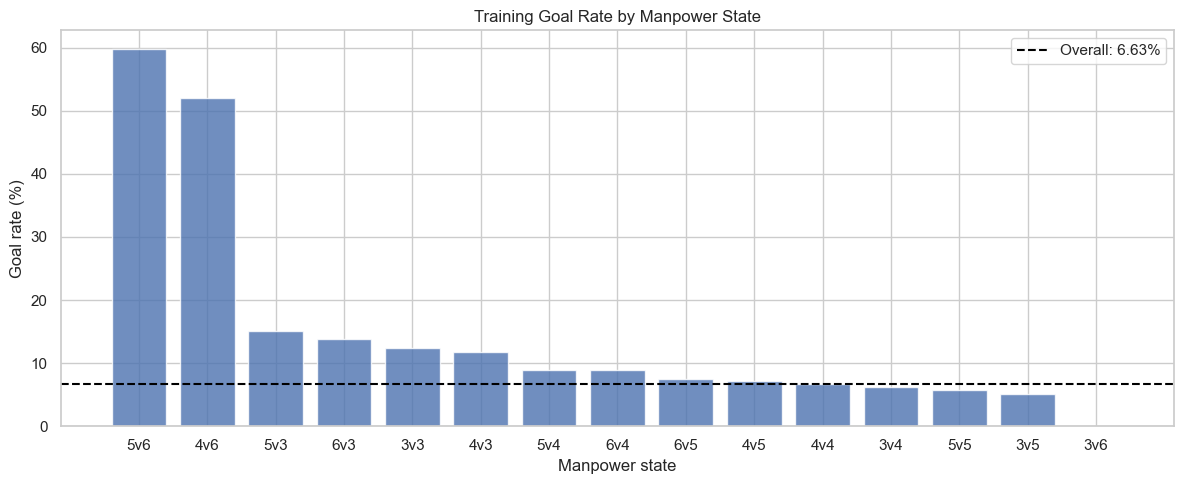


State           Shots    Goals     Rate vs Overall
--------------------------------------------------
5v6             9,153    5,471   59.77%    +53.14pp
4v6               667      347   52.02%    +45.39pp
5v3             9,433    1,426   15.12%     +8.49pp
6v3               123       17   13.82%     +7.19pp
3v3            13,538    1,687   12.46%     +5.83pp
4v3             5,292      626   11.83%     +5.20pp
5v4           259,316   23,281    8.98%     +2.35pp
6v4             4,349      385    8.85%     +2.22pp
6v5            30,201    2,249    7.45%     +0.82pp
4v5            44,397    3,169    7.14%     +0.51pp
4v4            33,503    2,229    6.65%     +0.02pp
3v4               273       17    6.23%     -0.40pp
5v5         1,443,244   81,999    5.68%     -0.95pp
3v5               315       16    5.08%     -1.55pp
3v6                 4        0    0.00%     -6.63pp

Even strength: 1,490,285 shots, 85,915 goals, rate = 5.77%

Power play: 308,714 shots, 27,984 goals, rate = 9.06%

S

In [4]:
cur.execute("""
    SELECT manpower_state,
           COUNT(*)          AS shots,
           SUM(is_goal)      AS goals,
           ROUND(CAST(SUM(is_goal) AS REAL) / COUNT(*), 4) AS goal_rate
    FROM training_shots
    WHERE manpower_state IS NOT NULL
    GROUP BY manpower_state
    ORDER BY goal_rate DESC
""")
mp_rows = cur.fetchall()

mp_states = [r[0] for r in mp_rows]
mp_shots = [r[1] for r in mp_rows]
mp_goals = [r[2] for r in mp_rows]
mp_rates = [r[3] for r in mp_rows]

fig, ax = plt.subplots(figsize=(12, 5))
ax.bar(mp_states, [r * 100 for r in mp_rates], alpha=0.8)
ax.axhline(y=overall_base_rate * 100, color="black", linestyle="--",
           label=f"Overall: {overall_base_rate*100:.2f}%")
ax.set_xlabel("Manpower state")
ax.set_ylabel("Goal rate (%)")
ax.set_title("Training Goal Rate by Manpower State")
ax.legend()
fig.tight_layout()
plt.show()

print(f"\n{'State':<10} {'Shots':>10} {'Goals':>8} {'Rate':>8} {'vs Overall':>10}")
print("-" * 50)
for st, sh, g, r in zip(mp_states, mp_shots, mp_goals, mp_rates):
    delta = (r - overall_base_rate) * 100
    print(f"{st:<10} {sh:>10,} {g:>8,} {r*100:>7.2f}% {delta:>+9.2f}pp")

EVEN_STRENGTH_STATES = {"5v5", "4v4", "3v3"}
PP_STATES = {"5v4", "5v3", "4v3", "6v5", "6v4", "6v3"}
SH_STATES = {"4v5", "3v5", "3v4", "5v6", "4v6", "3v6"}

for label, group in [("Even strength", EVEN_STRENGTH_STATES),
                     ("Power play", PP_STATES),
                     ("Short-handed", SH_STATES)]:
    group_shots = sum(sh for st, sh in zip(mp_states, mp_shots) if st in group)
    group_goals = sum(g for st, g in zip(mp_states, mp_goals) if st in group)
    group_rate = group_goals / group_shots if group_shots else 0
    print(f"\n{label}: {group_shots:,} shots, {group_goals:,} goals, "
          f"rate = {group_rate*100:.2f}%")


In [5]:
cur.execute("""
    SELECT period,
           COUNT(*)          AS shots,
           SUM(is_goal)      AS goals,
           ROUND(CAST(SUM(is_goal) AS REAL) / COUNT(*), 4) AS goal_rate
    FROM training_shots
    GROUP BY period
    ORDER BY period
""")
period_rows = cur.fetchall()

print(f"{'Period':<10} {'Shots':>10} {'Goals':>8} {'Rate':>8}")
print("-" * 40)
for r in period_rows:
    print(f"{r[0]:<10} {r[1]:>10,} {r[2]:>8,} {r[3]*100:>7.2f}%")

print("\nNote: Period 3 rate may be inflated by empty-net goals.")
print("OT periods (4+) have small samples and different rules (3v3 since 2015-16).")


Period          Shots    Goals     Rate
----------------------------------------
1             596,611   35,400    5.93%
2             633,167   42,030    6.64%
3             591,271   42,491    7.19%
4              31,567    2,932    9.29%
5                 953       56    5.88%
6                 161        8    4.97%
7                  66        1    1.52%
8                  12        1    8.33%

Note: Period 3 rate may be inflated by empty-net goals.
OT periods (4+) have small samples and different rules (3v3 since 2015-16).


In [6]:
TRACKING_ERA_FIRST_SEASON = "20192020"
COVID_SEASON = "20202021"

cur.execute("""
    SELECT
        CASE
            WHEN season = ? THEN 'COVID (2020-21)'
            WHEN season >= ? THEN 'Post-tracking (2019+)'
            ELSE 'Pre-tracking (<2019)'
        END AS era,
        COUNT(*)          AS shots,
        SUM(is_goal)      AS goals,
        ROUND(CAST(SUM(is_goal) AS REAL) / COUNT(*), 4) AS goal_rate
    FROM training_shots
    WHERE season IS NOT NULL
    GROUP BY era
    ORDER BY era
""", (COVID_SEASON, TRACKING_ERA_FIRST_SEASON))
era_rows = cur.fetchall()

print(f"{'Era':<30} {'Shots':>10} {'Goals':>8} {'Rate':>8} {'vs Overall':>10}")
print("-" * 70)
for r in era_rows:
    delta = (r[3] - overall_base_rate) * 100
    print(f"{r[0]:<30} {r[1]:>10,} {r[2]:>8,} {r[3]*100:>7.2f}% {delta:>+9.2f}pp")

print("\nIf era differences exceed 1pp, consider era-aware train/test splits")
print("or separate model intercepts per era.")


Era                                 Shots    Goals     Rate vs Overall
----------------------------------------------------------------------
COVID (2020-21)                    78,633    5,475    6.96%     +0.33pp
Post-tracking (2019+)             705,160   49,764    7.06%     +0.43pp
Pre-tracking (<2019)            1,070,015   67,680    6.33%     -0.30pp

If era differences exceed 1pp, consider era-aware train/test splits
or separate model intercepts per era.


In [7]:
# ── 1e. Step 1 summary ───────────────────────────────────────────────

print("=" * 60)
print("STEP 1 SUMMARY: Base Rate Stability")
print("=" * 60)
print(f"\nOverall base rate: {overall_base_rate*100:.2f}%")
print(f"Season range: {seasons[0]} to {seasons[-1]}" if seasons else "No season data")

# Compute spread
if season_rates:
    rate_min = min(season_rates)
    rate_max = max(season_rates)
    rate_spread_pp = (rate_max - rate_min) * 100
    print(f"Season rate range: {rate_min*100:.2f}% to {rate_max*100:.2f}% "
          f"(spread = {rate_spread_pp:.2f}pp)")

print(f"\nSeasons exceeding {BASE_RATE_DRIFT_THRESHOLD_PP}pp drift: "
      f"{len(flagged_seasons)}")

# Decision
if len(flagged_seasons) == 0:
    print("\nDECISION: Base rate is stable. A single intercept is likely sufficient.")
elif len(flagged_seasons) <= 2:
    print("\nDECISION: Minor drift detected. Monitor during temporal CV.")
    print("If calibration degrades on drifted seasons, add era as a feature.")
else:
    print("\nDECISION: Significant drift. Model MUST account for temporal shifts.")
    print("Options: era feature, season-specific intercepts, or recalibration layer.")

STEP 1 SUMMARY: Base Rate Stability

Overall base rate: 6.63%
Season range: 20092010 to 20252026
Season rate range: 6.20% to 7.18% (spread = 0.98pp)

Seasons exceeding 1.0pp drift: 0

DECISION: Base rate is stable. A single intercept is likely sufficient.


---
## Step 2: Statistical Rigor Retrofit

The existing EDA notebooks rely on visual inspection and point estimates. With 100k+ shots,
even tiny differences look "clear" in bar charts. This step adds:

- **Bootstrap 95% CIs** on goal rates per category
- **Chi-squared tests** for categorical features (is the goal-rate variation across categories real?)
- **Cohen's h effect sizes** to separate statistical significance from practical significance
- **Sample size adequacy** — flag cells with fewer than 400 shots (underpowered at 8% base rate)

We test four feature groups: shot type, manpower state, score state, and faceoff zone.

In [8]:
CATEGORICAL_FEATURE_COLUMNS = {
    "shot_type",
    "manpower_state",
    "score_state",
    "faceoff_zone_code",
}


def analyze_categorical_feature(cur, feature_column, feature_label):
    """Run the full statistical battery on a categorical training-shot feature.

    Returns a dict with chi2 results, per-category CIs, effect sizes, and
    sample-size flags.
    """
    if feature_column not in CATEGORICAL_FEATURE_COLUMNS:
        raise ValueError(f"Unsupported feature column: {feature_column}")

    cur.execute(f"""
        SELECT {feature_column},
               COUNT(*)     AS shots,
               SUM(is_goal) AS goals
        FROM training_shots
        WHERE {feature_column} IS NOT NULL
        GROUP BY {feature_column}
        ORDER BY COUNT(*) DESC
    """)
    rows = cur.fetchall()

    categories = [r[0] for r in rows]
    shots_list = [r[1] for r in rows]
    goals_list = [r[2] for r in rows]

    observed = np.array([[g, s - g] for g, s in zip(goals_list, shots_list)])
    chi2, p_value, dof, _ = sp_stats.chi2_contingency(observed)

    overall_rate = sum(goals_list) / sum(shots_list)
    results = []
    for cat, shots, goals in zip(categories, shots_list, goals_list):
        rate, ci_lo, ci_hi = bootstrap_goal_rate_ci(goals, shots)
        h = cohens_h(rate, overall_rate)
        underpowered = shots < MIN_SHOTS_PER_CELL
        results.append({
            "category": cat,
            "shots": shots,
            "goals": goals,
            "rate": rate,
            "ci_lower": ci_lo,
            "ci_upper": ci_hi,
            "cohens_h": h,
            "underpowered": underpowered,
        })

    return {
        "feature": feature_label,
        "chi2": chi2,
        "p_value": p_value,
        "dof": dof,
        "categories": results,
    }


def print_feature_analysis(analysis):
    """Pretty-print the results of analyze_categorical_feature."""
    feat = analysis["feature"]
    print(f"\n{'=' * 70}")
    print(f"Feature: {feat}")
    print(f"{'=' * 70}")
    p_display = "<0.0001" if analysis["p_value"] < 0.0001 else f"{analysis['p_value']:.4f}"
    print(f"Chi-squared: {analysis['chi2']:.2f}  (dof={analysis['dof']}, p={p_display})")

    sig = "YES" if analysis["p_value"] < 0.05 else "NO"
    print(f"Statistically significant variation: {sig}")

    print(f"\n{'Category':<20} {'Shots':>8} {'Goals':>7} {'Rate':>7} "
          f"{'95% CI':>15} {'Cohen h':>8} {'Power':>8}")
    print("-" * 78)

    for r in analysis["categories"]:
        ci_str = f"[{r['ci_lower']*100:.2f}, {r['ci_upper']*100:.2f}]"
        power_str = "LOW" if r["underpowered"] else "OK"
        h_str = f"{r['cohens_h']:+.3f}"
        print(f"{str(r['category']):<20} {r['shots']:>8,} {r['goals']:>7,} "
              f"{r['rate']*100:>6.2f}% {ci_str:>15} {h_str:>8} {power_str:>8}")

    meaningful = [r for r in analysis["categories"]
                  if abs(r["cohens_h"]) >= COHEN_H_SMALL and not r["underpowered"]]
    if meaningful:
        print(f"\nPractically meaningful categories (|Cohen's h| >= {COHEN_H_SMALL}):")
        for r in meaningful:
            print(f"  {r['category']}: h = {r['cohens_h']:+.3f}")
    else:
        print(f"\nNo categories reach Cohen's h >= {COHEN_H_SMALL} threshold.")

    underpowered = [r for r in analysis["categories"] if r["underpowered"]]
    if underpowered:
        print(f"\nUnderpowered categories (<{MIN_SHOTS_PER_CELL} shots):")
        for r in underpowered:
            print(f"  {r['category']}: {r['shots']:,} shots")

print("Helper functions defined (imports from src/validation.py).")


Helper functions defined (imports from src/validation.py).


In [9]:
# ── 2a. Shot type ────────────────────────────────────────────────────

shot_type_analysis = analyze_categorical_feature(cur, "shot_type", "Shot Type")
print_feature_analysis(shot_type_analysis)


Feature: Shot Type
Chi-squared: 6551.51  (dof=10, p=<0.0001)
Statistically significant variation: YES

Category                Shots   Goals    Rate          95% CI  Cohen h    Power
------------------------------------------------------------------------------
wrist                 928,742  60,108   6.47%    [6.42, 6.52]   -0.006       OK
slap                  322,374  13,429   4.17%    [4.10, 4.24]   -0.110       OK
snap                  277,459  20,959   7.55%    [7.46, 7.65]   +0.036       OK
backhand              138,686  11,458   8.26%    [8.12, 8.41]   +0.062       OK
tip-in                126,662  11,933   9.42%    [9.26, 9.58]   +0.103       OK
deflected              38,754   3,676   9.49%    [9.19, 9.78]   +0.105       OK
wrap-around            17,192     876   5.10%    [4.76, 5.43]   -0.065       OK
bat                     1,812     220  12.14%  [10.65, 13.63]   +0.191       OK
poke                    1,786     228  12.77%  [11.25, 14.33]   +0.210       OK
between-legs     

In [10]:
# ── 2b. Manpower state ───────────────────────────────────────────────

manpower_analysis = analyze_categorical_feature(cur, "manpower_state", "Manpower State")
print_feature_analysis(manpower_analysis)


Feature: Manpower State
Chi-squared: 50549.19  (dof=14, p=<0.0001)
Statistically significant variation: YES

Category                Shots   Goals    Rate          95% CI  Cohen h    Power
------------------------------------------------------------------------------
5v5                  1,443,244  81,999   5.68%    [5.64, 5.72]   -0.040       OK
5v4                   259,316  23,281   8.98%    [8.87, 9.09]   +0.088       OK
4v5                    44,397   3,169   7.14%    [6.90, 7.38]   +0.020       OK
4v4                    33,503   2,229   6.65%    [6.39, 6.92]   +0.001       OK
6v5                    30,201   2,249   7.45%    [7.15, 7.74]   +0.032       OK
3v3                    13,538   1,687  12.46%  [11.91, 13.02]   +0.201       OK
5v3                     9,433   1,426  15.12%  [14.40, 15.85]   +0.278       OK
5v6                     9,153   5,471  59.77%  [58.75, 60.78]   +1.247       OK
4v3                     5,292     626  11.83%  [10.96, 12.70]   +0.181       OK
6v4       

In [11]:
# ── 2c. Score state ──────────────────────────────────────────────────

score_state_analysis = analyze_categorical_feature(cur, "score_state", "Score State")
print_feature_analysis(score_state_analysis)


Feature: Score State
Chi-squared: 1961.43  (dof=6, p=<0.0001)
Statistically significant variation: YES

Category                Shots   Goals    Rate          95% CI  Cohen h    Power
------------------------------------------------------------------------------
tied                  674,597  41,501   6.15%    [6.10, 6.21]   -0.020       OK
down1                 356,509  22,082   6.19%    [6.12, 6.27]   -0.018       OK
up1                   307,774  22,701   7.38%    [7.28, 7.47]   +0.029       OK
down2                 170,979  10,704   6.26%    [6.15, 6.38]   -0.015       OK
up2                   136,763  11,993   8.77%    [8.62, 8.92]   +0.080       OK
down3plus             115,502   6,838   5.92%    [5.79, 6.06]   -0.029       OK
up3plus                91,684   7,100   7.74%    [7.57, 7.92]   +0.043       OK

No categories reach Cohen's h >= 0.2 threshold.


In [12]:
# ── 2d. Faceoff zone ─────────────────────────────────────────────────

faceoff_zone_analysis = analyze_categorical_feature(
    cur, "faceoff_zone_code", "Faceoff Zone Code"
)
print_feature_analysis(faceoff_zone_analysis)


Feature: Faceoff Zone Code
Chi-squared: 223.98  (dof=2, p=<0.0001)
Statistically significant variation: YES

Category                Shots   Goals    Rate          95% CI  Cohen h    Power
------------------------------------------------------------------------------
O                     705,848  47,755   6.77%    [6.71, 6.82]   +0.005       OK
D                     608,625  41,685   6.85%    [6.79, 6.91]   +0.009       OK
N                     538,466  33,421   6.21%    [6.14, 6.27]   -0.017       OK

No categories reach Cohen's h >= 0.2 threshold.


In [13]:
# ── 2e. Step 2 summary ───────────────────────────────────────────────

print("=" * 70)
print("STEP 2 SUMMARY: Statistical Rigor")
print("=" * 70)

all_analyses = [shot_type_analysis, manpower_analysis,
                score_state_analysis, faceoff_zone_analysis]

for a in all_analyses:
    sig = "significant" if a["p_value"] < 0.05 else "NOT significant"
    n_meaningful = sum(
        1 for r in a["categories"]
        if abs(r["cohens_h"]) >= COHEN_H_SMALL and not r["underpowered"]
    )
    n_underpowered = sum(1 for r in a["categories"] if r["underpowered"])
    print(f"\n{a['feature']}:")
    p_display = "<0.0001" if a["p_value"] < 0.0001 else f"{a['p_value']:.4f}"
    print(f"  Chi-squared {sig} (p={p_display})")
    print(f"  {n_meaningful} practically meaningful categories (|h| >= {COHEN_H_SMALL})")
    if n_underpowered:
        print(f"  {n_underpowered} underpowered categories (<{MIN_SHOTS_PER_CELL} shots)")

print("\nDECISION RULE:")
print("  - Feature is model-worthy if: chi-squared significant AND")
print("    at least 1 category with |Cohen's h| >= 0.2 AND adequate sample size")
print("  - Features that are only statistically significant (not practically)")
print("    may still be included but should not be expected to improve predictions.")

STEP 2 SUMMARY: Statistical Rigor

Shot Type:
  Chi-squared significant (p=<0.0001)
  1 practically meaningful categories (|h| >= 0.2)
  2 underpowered categories (<400 shots)

Manpower State:
  Chi-squared significant (p=<0.0001)
  4 practically meaningful categories (|h| >= 0.2)
  4 underpowered categories (<400 shots)

Score State:
  Chi-squared significant (p=<0.0001)
  0 practically meaningful categories (|h| >= 0.2)

Faceoff Zone Code:
  Chi-squared significant (p=<0.0001)
  0 practically meaningful categories (|h| >= 0.2)

DECISION RULE:
  - Feature is model-worthy if: chi-squared significant AND
    at least 1 category with |Cohen's h| >= 0.2 AND adequate sample size
  - Features that are only statistically significant (not practically)
    may still be included but should not be expected to improve predictions.


---
## Step 3: Temporal Cross-Validation Harness

All existing notebooks compute statistics on the full dataset. This step implements
**season-block cross-validation**: train on seasons 1..k, calibrate on season k+1,
and evaluate on season k+2.

The selected scorecard model uses only features that are unambiguously available at shot time
and already passed their audits:
- `distance_to_goal`
- `angle_to_goal`
- `shot_type` (fixed-category one-hot encoded)
- `manpower_state` (fixed-category one-hot encoded)
- `score_state` (fixed-category one-hot encoded)
- scaled `distance_to_goal x manpower_state` and `angle_to_goal x manpower_state` interactions

Faceoff, rest/travel, and venue-correction features remain excluded from the selected
candidate model until their separate audits pass. The simpler distance/angle/shot-type
model is retained as the ablation baseline in Step 5.


In [14]:
all_rows = training_rows
if not all_rows:
    raise RuntimeError("No training-eligible shots available for temporal CV.")

distances = np.array([r["distance_to_goal"] for r in all_rows], dtype=float)
angles = np.array([r["angle_to_goal"] for r in all_rows], dtype=float)
shot_types = [r["shot_type"] for r in all_rows]
manpower_states = [r["manpower_state"] for r in all_rows]
score_states = [r["score_state"] for r in all_rows]
seconds_since_fo = [r["seconds_since_faceoff"] for r in all_rows]
fo_zones = [r["faceoff_zone_code"] for r in all_rows]
is_goal = np.array([r["is_goal"] for r in all_rows], dtype=int)
row_seasons = [str(r["season"]) for r in all_rows]

unique_seasons = sorted(set(row_seasons))
print(f"Loaded {len(all_rows):,} training-eligible shots across {len(unique_seasons)} seasons")
print(f"Seasons: {unique_seasons[0]} to {unique_seasons[-1]}")
print(f"Goal rate: {is_goal.mean()*100:.2f}%")


Loaded 1,853,808 training-eligible shots across 17 seasons
Seasons: 20092010 to 20252026
Goal rate: 6.63%


In [15]:
# ?? 3b. Build selected scorecard feature matrix ?????????????????????
# Selected baseline: distance, angle, shot_type, manpower_state, score_state,
# plus manpower-specific distance/angle slopes. Fixed category lists keep
# feature columns stable across notebook runs.

DISTANCE_INTERACTION_SCALE = 100.0
ANGLE_INTERACTION_SCALE = 90.0

shot_type_categories = sorted(VALID_SHOT_TYPES)
manpower_categories = sorted(VALID_MANPOWER_STATES)
score_state_categories = sorted(VALID_SCORE_STATES)

shot_type_encoder = OneHotEncoder(
    categories=[shot_type_categories], sparse_output=False, handle_unknown="ignore"
)
shot_type_encoded = shot_type_encoder.fit_transform(
    np.array(shot_types).reshape(-1, 1)
)

mp_encoder = OneHotEncoder(
    categories=[manpower_categories], sparse_output=False, handle_unknown="ignore"
)
mp_encoded = mp_encoder.fit_transform(
    np.array(manpower_states).reshape(-1, 1)
)

ss_encoder = OneHotEncoder(
    categories=[score_state_categories], sparse_output=False, handle_unknown="ignore"
)
ss_encoded = ss_encoder.fit_transform(
    np.array(score_states).reshape(-1, 1)
)

mp_distance_interactions = mp_encoded * (distances / DISTANCE_INTERACTION_SCALE).reshape(-1, 1)
mp_angle_interactions = mp_encoded * (angles / ANGLE_INTERACTION_SCALE).reshape(-1, 1)

X_core_baseline = np.column_stack([distances, angles, shot_type_encoded])
X_selected = np.column_stack([
    X_core_baseline,
    mp_encoded,
    ss_encoded,
    mp_distance_interactions,
    mp_angle_interactions,
])
y = is_goal

core_baseline_feature_names = (
    ["distance_to_goal", "angle_to_goal"]
    + [f"shot_type_{c}" for c in shot_type_encoder.categories_[0]]
)
selected_feature_names = (
    core_baseline_feature_names
    + [f"manpower_state_{c}" for c in mp_encoder.categories_[0]]
    + [f"score_state_{c}" for c in ss_encoder.categories_[0]]
    + [f"distance_x_manpower_{c}" for c in mp_encoder.categories_[0]]
    + [f"angle_x_manpower_{c}" for c in mp_encoder.categories_[0]]
)
selected_model_features = [
    "distance_to_goal",
    "angle_to_goal",
    "shot_type",
    "manpower_state",
    "score_state",
    "distance_x_manpower_state",
    "angle_x_manpower_state",
]

print(f"Core ablation baseline matrix: {X_core_baseline.shape}")
print(f"Selected scorecard feature matrix: {X_selected.shape}")
print(f"Selected feature families: {selected_model_features}")
print("Selected interactions: distance_to_goal x manpower_state, angle_to_goal x manpower_state")
print(f"Feature columns: {selected_feature_names}")


Core ablation baseline matrix: (1853808, 13)
Selected scorecard feature matrix: (1853808, 65)
Selected feature families: ['distance_to_goal', 'angle_to_goal', 'shot_type', 'manpower_state', 'score_state', 'distance_x_manpower_state', 'angle_x_manpower_state']
Selected interactions: distance_to_goal x manpower_state, angle_to_goal x manpower_state
Feature columns: ['distance_to_goal', 'angle_to_goal', 'shot_type_backhand', 'shot_type_bat', 'shot_type_between-legs', 'shot_type_cradle', 'shot_type_deflected', 'shot_type_poke', 'shot_type_slap', 'shot_type_snap', 'shot_type_tip-in', 'shot_type_wrap-around', 'shot_type_wrist', 'manpower_state_3v3', 'manpower_state_3v4', 'manpower_state_3v5', 'manpower_state_3v6', 'manpower_state_4v3', 'manpower_state_4v4', 'manpower_state_4v5', 'manpower_state_4v6', 'manpower_state_5v3', 'manpower_state_5v4', 'manpower_state_5v5', 'manpower_state_5v6', 'manpower_state_6v3', 'manpower_state_6v4', 'manpower_state_6v5', 'score_state_down1', 'score_state_down2'

In [16]:
# ?? 3c. Season-block temporal CV with prior-season calibration ?????
# Base train: seasons before the immediately prior season.
# Platt calibrator: immediately prior season only.
# Test: next season. MIN_TRAIN_SEASONS comes from src/validation.py.

row_seasons_arr = np.array(row_seasons)

cv_results = run_temporal_cv_with_prior_season_calibration(
    X_selected, y, row_seasons_arr, unique_seasons, min_train=MIN_TRAIN_SEASONS
)

for fold_idx, r in enumerate(cv_results, start=1):
    print(f"  Fold {fold_idx}: train seasons={r['train_seasons']}  "
          f"cal={r['calibration_season']}  test={r['test_season']}  "
          f"n_train={r['n_train']:,}  n_cal={r['n_calibration']:,}  "
          f"n_test={r['n_test']:,}  AUC={r['auc_roc']:.4f}  "
          f"LogLoss={r['log_loss']:.4f}  Brier={r['brier']:.4f}")

if cv_results:
    print(f"\nFirst calibrated test fold: {cv_results[0]['test_season']}")
print(f"{len(cv_results)} calibrated folds completed.")


  Fold 1: train seasons=3  cal=20122013  test=20132014  n_train=328,905  n_cal=65,839  n_test=110,263  AUC=0.7527  LogLoss=0.2075  Brier=0.0546
  Fold 2: train seasons=4  cal=20132014  test=20142015  n_train=394,744  n_cal=110,263  n_test=109,215  AUC=0.7525  LogLoss=0.2068  Brier=0.0542
  Fold 3: train seasons=5  cal=20142015  test=20152016  n_train=505,007  n_cal=109,215  n_test=109,012  AUC=0.7607  LogLoss=0.2057  Brier=0.0541
  Fold 4: train seasons=6  cal=20152016  test=20162017  n_train=614,222  n_cal=109,012  n_test=110,442  AUC=0.7544  LogLoss=0.2074  Brier=0.0545
  Fold 5: train seasons=7  cal=20162017  test=20172018  n_train=723,234  n_cal=110,442  n_test=119,172  AUC=0.7507  LogLoss=0.2120  Brier=0.0560
  Fold 6: train seasons=8  cal=20172018  test=20182019  n_train=833,676  n_cal=119,172  n_test=117,167  AUC=0.7521  LogLoss=0.2155  Brier=0.0573
  Fold 7: train seasons=9  cal=20182019  test=20192020  n_train=952,848  n_cal=117,167  n_test=104,337  AUC=0.7596  LogLoss=0.2209 

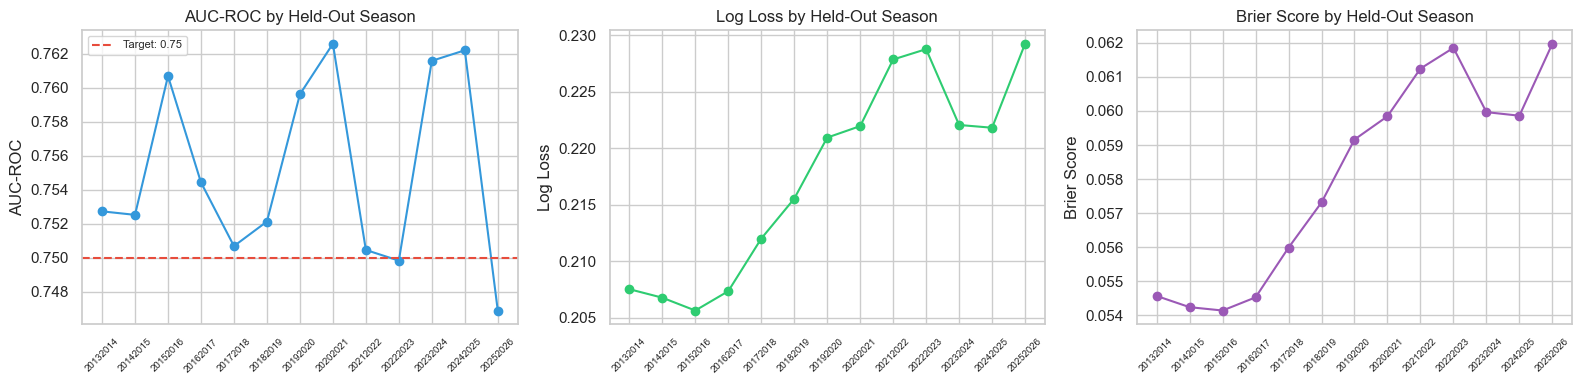


Selected calibrated model (distance + angle + shot_type + manpower_state + score_state + manpower interactions):
  Mean AUC-ROC: 0.7551 +/- 0.0052
  Mean Log Loss: 0.2175
  Mean Brier:    0.0581
  AUC target (0.75): MET

  AUC trend: slope = +0.0001/season (p=0.8670)
  AUC stable (drift < 0.02/season)


In [17]:
# ── 3d. Temporal CV summary + drift detection ───────────────────────

AUC_TARGET = 0.75
AUC_DRIFT_THRESHOLD_PER_SEASON = 0.02

if cv_results:
    test_seasons_cv = [r["test_season"] for r in cv_results]
    aucs = [r["auc_roc"] for r in cv_results]
    log_losses = [r["log_loss"] for r in cv_results]
    briers = [r["brier"] for r in cv_results]

    fig, axes = plt.subplots(1, 3, figsize=(16, 4))

    axes[0].plot(test_seasons_cv, aucs, "o-", color="#3498db")
    axes[0].axhline(y=AUC_TARGET, color="#e74c3c", linestyle="--",
                    label=f"Target: {AUC_TARGET}")
    axes[0].set_ylabel("AUC-ROC")
    axes[0].set_title("AUC-ROC by Held-Out Season")
    axes[0].legend(fontsize=8)

    axes[1].plot(test_seasons_cv, log_losses, "o-", color="#2ecc71")
    axes[1].set_ylabel("Log Loss")
    axes[1].set_title("Log Loss by Held-Out Season")

    axes[2].plot(test_seasons_cv, briers, "o-", color="#9b59b6")
    axes[2].set_ylabel("Brier Score")
    axes[2].set_title("Brier Score by Held-Out Season")

    for ax in axes:
        ax.tick_params(axis="x", rotation=45, labelsize=7)

    fig.tight_layout()
    plt.show()

    # Summary stats
    mean_auc = np.mean(aucs)
    std_auc = np.std(aucs)
    print(f"\nSelected calibrated model (distance + angle + shot_type + manpower_state + score_state + manpower interactions):")
    print(f"  Mean AUC-ROC: {mean_auc:.4f} +/- {std_auc:.4f}")
    print(f"  Mean Log Loss: {np.mean(log_losses):.4f}")
    print(f"  Mean Brier:    {np.mean(briers):.4f}")
    print(f"  AUC target ({AUC_TARGET}): {'MET' if mean_auc >= AUC_TARGET else 'NOT MET'}")

    # Drift detection: linear trend in AUC
    if len(aucs) >= 3:
        x_trend = np.arange(len(aucs))
        auc_drift_slope, auc_drift_intercept, auc_drift_r_value, auc_drift_p_value, auc_drift_std_err = sp_stats.linregress(x_trend, aucs)
        print(f"\n  AUC trend: slope = {auc_drift_slope:+.4f}/season (p={auc_drift_p_value:.4f})")
        if abs(auc_drift_slope) > AUC_DRIFT_THRESHOLD_PER_SEASON:
            print(f"  WARNING: AUC drift exceeds {AUC_DRIFT_THRESHOLD_PER_SEASON}/season threshold")
        else:
            print(f"  AUC stable (drift < {AUC_DRIFT_THRESHOLD_PER_SEASON}/season)")
else:
    print("No CV results to summarize.")

---
## Step 4: Calibration Analysis

For a rare-event model (~8% base rate), calibration matters more than discrimination.
A naive model predicting 0.08 for every shot achieves decent log loss. The model must
produce probabilities that are *accurate*, not just *ranked correctly*.

**Checks:**
- Reliability diagram (calibration curve) pooled across all calibrated folds
- Practical calibration gates: slope, max decile error, and expected calibration error
- Per-segment calibration: even strength, power play, short-handed
- Hosmer-Lemeshow goodness-of-fit statistic reported as a diagnostic only
- Calibration slope and intercept per held-out season


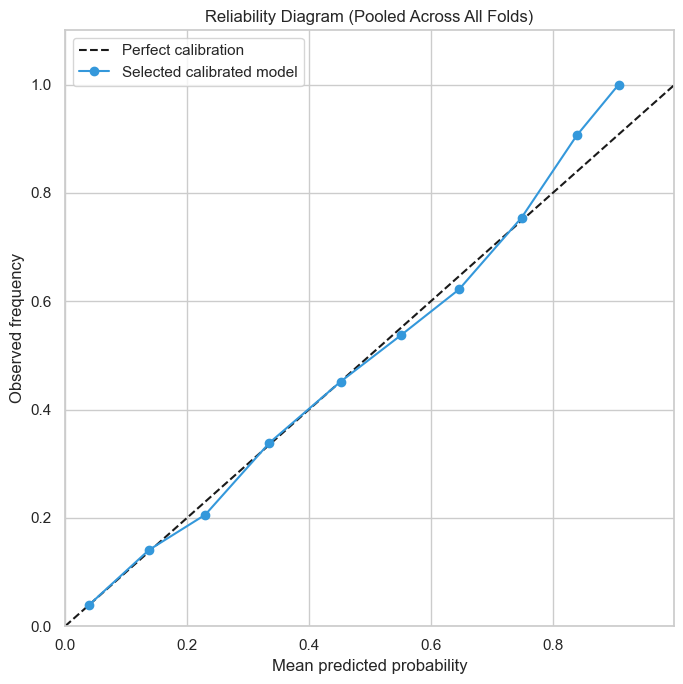

Hosmer-Lemeshow diagnostic: statistic=277.07, dof=8, p=0


  Diagnostic only: pass/fail uses practical calibration gates below.



Calibration slope: 0.9870  (target: [0.95, 1.05])
Calibration intercept: -0.0291  (target: near 0)
  Slope in target range: YES

Practical calibration metrics:
  Max decile calibration error: 0.407pp (target: < 1.0pp)
  Expected calibration error:   0.193pp (target: < 0.5pp)


In [18]:
# ?? 4a. Pooled calibration curve ?????????????????????????????????????
# Practical calibration gates come from src/validation.py. Hosmer-Lemeshow
# remains reported, but is diagnostic only on million-row holdout pools.

if cv_results:
    # Pool all held-out predictions
    y_pool = np.concatenate([r["y_test"] for r in cv_results])
    prob_pool = np.concatenate([r["y_prob"] for r in cv_results])

    # Calibration curve
    prob_true, prob_pred = calibration_curve(y_pool, prob_pool, n_bins=CALIBRATION_N_BINS)

    fig, ax = plt.subplots(figsize=(7, 7))
    ax.plot([0, 1], [0, 1], "k--", label="Perfect calibration")
    ax.plot(prob_pred, prob_true, "o-", color="#3498db", label="Selected calibrated model")
    ax.set_xlabel("Mean predicted probability")
    ax.set_ylabel("Observed frequency")
    ax.set_title("Reliability Diagram (Pooled Across All Folds)")
    ax.legend()
    ax.set_xlim(0, max(0.3, prob_pred.max() * 1.1))
    ax.set_ylim(0, max(0.3, prob_true.max() * 1.1))
    fig.tight_layout()
    plt.show()

    hl_stat, hl_p, hl_dof = hosmer_lemeshow_test(y_pool, prob_pool)
    print(f"Hosmer-Lemeshow diagnostic: statistic={hl_stat:.2f}, dof={hl_dof}, p={hl_p:.4g}")
    print("  Diagnostic only: pass/fail uses practical calibration gates below.")

    slope, intercept = calibration_slope_intercept(y_pool, prob_pool)
    print(f"\nCalibration slope: {slope:.4f}  (target: [{CALIBRATION_SLOPE_TARGET_LOW}, {CALIBRATION_SLOPE_TARGET_HIGH}])")
    print(f"Calibration intercept: {intercept:.4f}  (target: near 0)")
    in_range = CALIBRATION_SLOPE_TARGET_LOW <= slope <= CALIBRATION_SLOPE_TARGET_HIGH
    print(f"  Slope in target range: {'YES' if in_range else 'NO'}")

    practical_calibration = practical_calibration_metrics(y_pool, prob_pool)
    max_bin_error = practical_calibration["max_bin_calibration_error"]
    ece = practical_calibration["expected_calibration_error"]
    print("\nPractical calibration metrics:")
    print(f"  Max decile calibration error: {max_bin_error*100:.3f}pp "
          f"(target: < {MAX_DECILE_CALIBRATION_ERROR*100:.1f}pp)")
    print(f"  Expected calibration error:   {ece*100:.3f}pp "
          f"(target: < {EXPECTED_CALIBRATION_ERROR_TARGET*100:.1f}pp)")
else:
    practical_calibration = None
    print("No CV results for calibration analysis.")


In [19]:
# ?? 4b. Per-segment calibration (ES / PP / SH) ?????????????????????
# Check that the model is not systematically miscalibrated for any
# manpower segment. This is critical because PP goal rates are ~2x ES.

MAX_SUBGROUP_CALIBRATION_ERROR = 0.03

if cv_results:
    # Rebuild manpower arrays aligned to the calibrated CV test folds.
    mp_arr = np.array(manpower_states)

    segment_defs = {
        "Even Strength": EVEN_STRENGTH_STATES,
        "Power Play": PP_STATES,
        "Short-Handed": SH_STATES,
    }

    test_indices_all = []
    for r in cv_results:
        test_mask = row_seasons_arr == r["test_season"]
        test_indices_all.extend(np.where(test_mask)[0])

    test_indices_all = np.array(test_indices_all)
    mp_test = mp_arr[test_indices_all]

    print(f"{'Segment':<20} {'Shots':>8} {'Obs Rate':>9} {'Pred Rate':>10} "
          f"{'Cal Error':>10} {'HL p-val':>9} {'Status':>8}")
    print("-" * 78)

    segment_results = {}
    for seg_name, seg_states in segment_defs.items():
        seg_mask = np.array([m in seg_states for m in mp_test])

        if seg_mask.sum() == 0:
            print(f"{seg_name:<20} {'No data':>8}")
            continue

        y_seg = y_pool[seg_mask]
        p_seg = prob_pool[seg_mask]

        obs_rate = y_seg.mean()
        pred_rate = p_seg.mean()
        cal_error = abs(obs_rate - pred_rate)

        hl_s, hl_p_segment, _ = hosmer_lemeshow_test(y_seg, p_seg)
        status = "PASS" if cal_error < MAX_SUBGROUP_CALIBRATION_ERROR else "FAIL"

        segment_results[seg_name] = {
            "n": seg_mask.sum(),
            "obs_rate": obs_rate,
            "pred_rate": pred_rate,
            "cal_error": cal_error,
            "hl_p": hl_p_segment,
            "status": status,
        }

        print(f"{seg_name:<20} {seg_mask.sum():>8,} {obs_rate*100:>8.2f}% "
              f"{pred_rate*100:>9.2f}% {cal_error*100:>9.2f}pp "
              f"{hl_p_segment:>9.4f} {status:>8}")

    print(f"\nMax acceptable calibration error: {MAX_SUBGROUP_CALIBRATION_ERROR*100:.1f}pp")
else:
    segment_results = {}
    print("No CV results for segment calibration.")


Segment                 Shots  Obs Rate  Pred Rate  Cal Error  HL p-val   Status
------------------------------------------------------------------------------


Even Strength        1,176,720     5.82%      5.84%      0.02pp    0.0000     PASS


Power Play            238,647     9.18%      9.28%      0.10pp    0.0000     PASS


Short-Handed           43,697    17.37%     16.13%      1.24pp    0.0000     PASS

Max acceptable calibration error: 3.0pp


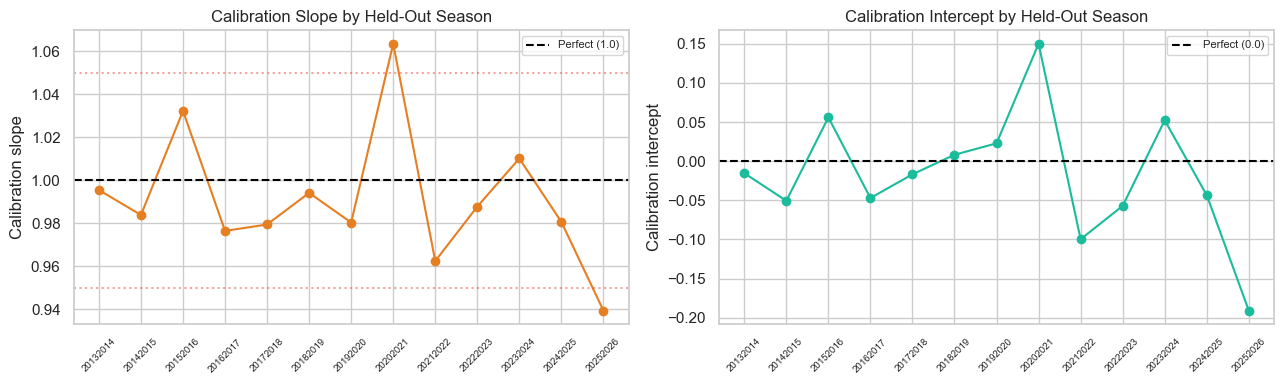

\nSeason          Slope  Intercept  Slope OK?
--------------------------------------------
20132014       0.9955    -0.0153        YES
20142015       0.9839    -0.0506        YES
20152016       1.0323     0.0560        YES
20162017       0.9765    -0.0471        YES
20172018       0.9795    -0.0168        YES
20182019       0.9942     0.0083        YES
20192020       0.9804     0.0228        YES
20202021       1.0635     0.1501         NO
20212022       0.9625    -0.0997        YES
20222023       0.9878    -0.0571        YES
20232024       1.0102     0.0523        YES
20242025       0.9807    -0.0433        YES
20252026       0.9394    -0.1908         NO


In [20]:
# ── 4c. Calibration slope per held-out season ────────────────────────
# Track whether calibration degrades over time (concept drift).

if cv_results:
    cal_slopes = []
    cal_intercepts = []
    for r in cv_results:
        s, i = calibration_slope_intercept(r["y_test"], r["y_prob"])
        cal_slopes.append(s)
        cal_intercepts.append(i)

    fig, (ax1, ax2) = plt.subplots(1, 2, figsize=(13, 4))

    ax1.plot(test_seasons_cv, cal_slopes, "o-", color="#e67e22")
    ax1.axhline(y=1.0, color="black", linestyle="--", label="Perfect (1.0)")
    ax1.axhline(y=CALIBRATION_SLOPE_TARGET_LOW, color="#e74c3c", linestyle=":", alpha=0.5)
    ax1.axhline(y=CALIBRATION_SLOPE_TARGET_HIGH, color="#e74c3c", linestyle=":", alpha=0.5)
    ax1.set_ylabel("Calibration slope")
    ax1.set_title("Calibration Slope by Held-Out Season")
    ax1.legend(fontsize=8)
    ax1.tick_params(axis="x", rotation=45, labelsize=7)

    ax2.plot(test_seasons_cv, cal_intercepts, "o-", color="#1abc9c")
    ax2.axhline(y=0.0, color="black", linestyle="--", label="Perfect (0.0)")
    ax2.set_ylabel("Calibration intercept")
    ax2.set_title("Calibration Intercept by Held-Out Season")
    ax2.legend(fontsize=8)
    ax2.tick_params(axis="x", rotation=45, labelsize=7)

    fig.tight_layout()
    plt.show()

    # Per-season table
    print(f"\\n{'Season':<12} {'Slope':>8} {'Intercept':>10} {'Slope OK?':>10}")
    print("-" * 44)
    for s, sl, ic in zip(test_seasons_cv, cal_slopes, cal_intercepts):
        ok = "YES" if CALIBRATION_SLOPE_TARGET_LOW <= sl <= CALIBRATION_SLOPE_TARGET_HIGH else "NO"
        print(f"{s:<12} {sl:>8.4f} {ic:>10.4f} {ok:>10}")
else:
    print("No CV results for per-season calibration.")

---
## Step 5: Conditional Feature Importance (Ablation)

The existing notebooks ask "does this feature correlate with goals?" but never
"does adding this feature to a model that already includes distance + angle + shot type
improve predictions?" This step answers the second question.

For each candidate feature group, we compare **baseline + feature** vs. **baseline only**
using the same temporal CV harness from Step 3.

**Feature groups tested:**
1. Manpower state (one-hot)
2. Score state (one-hot)
3. Faceoff zone code (one-hot)
4. Faceoff recency: continuous log(seconds_since_faceoff + 1) vs. binned
5. Combined: all of the above

In [21]:
# ?? 5a. Build augmented feature matrices ?????????????????????????????
# Reuse the fixed-category encoders from the selected model for manpower/score.

# Faceoff zone code (one-hot)
fz_encoder = OneHotEncoder(sparse_output=False, handle_unknown="ignore")
fz_encoded = fz_encoder.fit_transform(
    np.array([z if z else "UNKNOWN" for z in fo_zones]).reshape(-1, 1)
)

# Faceoff recency - continuous: log(seconds_since_faceoff + 1)
fo_seconds = np.array([s if s is not None else -1 for s in seconds_since_fo], dtype=float)
fo_has_value = fo_seconds >= 0
fo_log_values = np.zeros_like(fo_seconds, dtype=float)
fo_log_values[fo_has_value] = np.log1p(fo_seconds[fo_has_value])
fo_log_continuous = fo_log_values.reshape(-1, 1)
fo_missing_flag = (~fo_has_value).astype(float).reshape(-1, 1)
X_fo_continuous = np.column_stack([fo_log_continuous, fo_missing_flag])

# Faceoff recency - binned (replicating existing notebook approach)
FACEOFF_BIN_EDGES = [0, 5, 10, 20, 40, np.inf]  # seconds
FACEOFF_BIN_LABELS = ["0-5s", "6-10s", "11-20s", "21-40s", "40s+"]
fo_bins = np.full(len(fo_seconds), "UNKNOWN", dtype=object)
for i, s in enumerate(fo_seconds):
    if s < 0:
        continue
    for j in range(len(FACEOFF_BIN_EDGES) - 1):
        if FACEOFF_BIN_EDGES[j] <= s < FACEOFF_BIN_EDGES[j + 1]:
            fo_bins[i] = FACEOFF_BIN_LABELS[j]
            break

fo_bin_encoder = OneHotEncoder(sparse_output=False, handle_unknown="ignore")
X_fo_binned = fo_bin_encoder.fit_transform(fo_bins.reshape(-1, 1))

# Define feature-group augmentations against the simpler core baseline.
feature_groups = {
    "manpower_state": mp_encoded,
    "score_state": ss_encoded,
    "faceoff_zone": fz_encoded,
    "faceoff_recency_continuous": X_fo_continuous,
    "faceoff_recency_binned": X_fo_binned,
    "all_combined": np.column_stack([
        mp_encoded, ss_encoded, fz_encoded, X_fo_continuous
    ]),
}

for name, X_extra in feature_groups.items():
    print(f"  {name}: {X_extra.shape[1]} extra columns")


  manpower_state: 15 extra columns
  score_state: 7 extra columns
  faceoff_zone: 4 extra columns
  faceoff_recency_continuous: 2 extra columns
  faceoff_recency_binned: 6 extra columns
  all_combined: 28 extra columns


In [22]:
# ?? 5b. Ablation: run temporal CV for each feature group ?????????????
# run_temporal_cv comes from src/validation.py. Ablation uses the simpler
# distance/angle/shot-type model, so selected features can still be ranked.

core_baseline_cv_results = run_temporal_cv(
    X_core_baseline, y, row_seasons_arr, unique_seasons, min_train=MIN_TRAIN_SEASONS
)

baseline_metrics = {
    "mean_auc": np.mean([r["auc_roc"] for r in core_baseline_cv_results]),
    "mean_log_loss": np.mean([r["log_loss"] for r in core_baseline_cv_results]),
    "mean_brier": np.mean([r["brier"] for r in core_baseline_cv_results]),
}

# Run ablation for each feature group
ablation_results = {}
for group_name, X_extra in feature_groups.items():
    X_aug = np.column_stack([X_core_baseline, X_extra])
    fold_results = run_temporal_cv(
        X_aug, y, row_seasons_arr, unique_seasons, min_train=MIN_TRAIN_SEASONS
    )

    if fold_results:
        mean_auc = np.mean([r["auc_roc"] for r in fold_results])
        mean_ll = np.mean([r["log_loss"] for r in fold_results])
        mean_brier = np.mean([r["brier"] for r in fold_results])
        ablation_results[group_name] = {
            "mean_auc": mean_auc,
            "mean_log_loss": mean_ll,
            "mean_brier": mean_brier,
            "delta_auc": mean_auc - baseline_metrics["mean_auc"],
            "delta_log_loss": mean_ll - baseline_metrics["mean_log_loss"],
            "delta_brier": mean_brier - baseline_metrics["mean_brier"],
            "folds": fold_results,
        }

# Print ablation table
print(f"\n{'Feature Group':<30} {'AUC':>7} {'dAUC':>7} {'LogLoss':>8} {'dLL':>7} "
      f"{'Brier':>7} {'dBrier':>7}")
print("-" * 78)
print(f"{'CORE BASELINE (dist+angle+type)':<30} {baseline_metrics['mean_auc']:>7.4f} "
      f"{'---':>7} {baseline_metrics['mean_log_loss']:>8.4f} {'---':>7} "
      f"{baseline_metrics['mean_brier']:>7.4f} {'---':>7}")

for name, res in ablation_results.items():
    auc_arrow = "+" if res["delta_auc"] > 0 else ""
    print(f"{name:<30} {res['mean_auc']:>7.4f} {auc_arrow}{res['delta_auc']:>6.4f} "
          f"{res['mean_log_loss']:>8.4f} {res['delta_log_loss']:>+6.4f} "
          f"{res['mean_brier']:>7.4f} {res['delta_brier']:>+6.4f}")

print("\nPositive dAUC = improvement. Negative dLogLoss/dBrier = improvement.")



Feature Group                      AUC    dAUC  LogLoss     dLL   Brier  dBrier
------------------------------------------------------------------------------
CORE BASELINE (dist+angle+type)  0.7208     ---   0.2287     ---  0.0597     ---
manpower_state                  0.7495 +0.0287   0.2188 -0.0099  0.0582 -0.0015
score_state                     0.7216 +0.0009   0.2282 -0.0004  0.0596 -0.0000
faceoff_zone                    0.7210 +0.0002   0.2287 -0.0000  0.0597 -0.0000
faceoff_recency_continuous      0.7217 +0.0009   0.2285 -0.0002  0.0596 -0.0000
faceoff_recency_binned          0.7218 +0.0010   0.2285 -0.0002  0.0596 -0.0000
all_combined                    0.7506 +0.0298   0.2185 -0.0102  0.0581 -0.0016

Positive dAUC = improvement. Negative dLogLoss/dBrier = improvement.


In [23]:
# ── 5c. Continuous vs. binned faceoff recency comparison ─────────────
# The existing notebooks use arbitrary round-number bins (0-5s, 6-10s, etc.).
# The exponential decay analysis suggests continuous is more natural.

if "faceoff_recency_continuous" in ablation_results and "faceoff_recency_binned" in ablation_results:
    cont = ablation_results["faceoff_recency_continuous"]
    binned = ablation_results["faceoff_recency_binned"]

    print("Faceoff Recency: Continuous vs. Binned")
    print("=" * 50)
    print(f"  {'Representation':<25} {'AUC':>7} {'LogLoss':>8} {'Brier':>7}")
    print(f"  {'-' * 47}")
    print(f"  {'Continuous (log1p):':<25} {cont['mean_auc']:>7.4f} "
          f"{cont['mean_log_loss']:>8.4f} {cont['mean_brier']:>7.4f}")
    print(f"  {'Binned (5s/10s/20s/40s):':<25} {binned['mean_auc']:>7.4f} "
          f"{binned['mean_log_loss']:>8.4f} {binned['mean_brier']:>7.4f}")

    auc_diff = cont["mean_auc"] - binned["mean_auc"]
    winner = "Continuous" if auc_diff > 0 else "Binned"
    print(f"\n  AUC difference: {auc_diff:+.4f} ({winner} wins)")
    print(f"  Recommendation: Use {'continuous' if auc_diff >= 0 else 'binned'} representation")
    if abs(auc_diff) < 0.001:
        print("  (Difference is negligible — either is fine)")
else:
    print("Faceoff recency ablation results not available.")

Faceoff Recency: Continuous vs. Binned
  Representation                AUC  LogLoss   Brier
  -----------------------------------------------
  Continuous (log1p):        0.7217   0.2285  0.0596
  Binned (5s/10s/20s/40s):   0.7218   0.2285  0.0596

  AUC difference: -0.0000 (Binned wins)
  Recommendation: Use binned representation
  (Difference is negligible — either is fine)


---
## Step 5b: Venue Bias - Prior-Season Validation

The existing `venue_bias_analysis.ipynb` computes per-season z-scores and checks
seasonal stability. Same-season venue diagnostics cannot be used inside temporal CV
because they are computed from outcomes in the held-out season. This step validates
venue-bias features using only diagnostics from seasons before each shot:

1. Does a prior-season mean venue z-score improve held-out model performance?
2. Does the most recent prior-season z-score outperform the prior-season mean?
3. Are there scorer turnover effects (z-score sign flips between seasons)?


In [24]:
cur.execute("""
    SELECT venue_name, season, shot_count_z_score
    FROM venue_bias_diagnostics
    WHERE shot_count_z_score IS NOT NULL
    ORDER BY venue_name, season
""")
vd_rows = cur.fetchall()

from collections import defaultdict
venue_z_by_season = defaultdict(list)
for r in vd_rows:
    venue_z_by_season[r[0]].append((str(r[1]), r[2]))

MIN_SEASONS_FOR_STABILITY = 3
sign_flip_venues = []

for venue, season_z_list in venue_z_by_season.items():
    if len(season_z_list) < MIN_SEASONS_FOR_STABILITY:
        continue
    flips = 0
    for i in range(1, len(season_z_list)):
        prev_z = season_z_list[i - 1][1]
        curr_z = season_z_list[i][1]
        if prev_z * curr_z < 0 and (abs(prev_z) > 1.0 or abs(curr_z) > 1.0):
            flips += 1
    if flips > 0:
        sign_flip_venues.append((venue, flips, len(season_z_list)))

if sign_flip_venues:
    print(f"Venues with z-score sign flips (potential scorer turnover):")
    print(f"{'Venue':<35} {'Flips':>6} {'Seasons':>8}")
    print("-" * 52)
    for venue, flips, n_seasons in sorted(sign_flip_venues, key=lambda x: -x[1]):
        print(f"{venue:<35} {flips:>6} {n_seasons:>8}")
    print(f"\n{len(sign_flip_venues)} venues show sign flips.")
    print("These venues need per-season correction (pooled would cancel out).")
else:
    print("No significant z-score sign flips detected.")

Venues with z-score sign flips (potential scorer turnover):
Venue                                Flips  Seasons
----------------------------------------------------
Barclays Center                          2        6
Bridgestone Arena                        2       17
Nationwide Arena                         2       19
Amalie Arena                             1       11
CONSOL Energy Center                     1        7
Centre Bell                              1       19
General Motors Place                     1        4
HP Pavilion at San Jose                  1        5
Jobing.com Arena                         1        6
MTS Centre                               1        7
Prudential Center                        1       19
St. Pete Times Forum                     1        5
Verizon Center                           1       11
Wachovia Center                          1        3

14 venues show sign flips.
These venues need per-season correction (pooled would cancel out).


In [25]:
shot_venues = [row["venue_name"] for row in all_rows]
shot_seasons_for_venue = [str(row["season"]) for row in all_rows]


def build_prior_venue_z_feature(mode):
    """Return a fold-safe venue-z feature using seasons before each shot only."""
    values = []
    for venue, season in zip(shot_venues, shot_seasons_for_venue):
        if not venue:
            values.append(0.0)
            continue

        prior_values = [
            (prior_season, z_score)
            for prior_season, z_score in venue_z_by_season.get(venue, [])
            if prior_season < season
        ]
        if not prior_values:
            values.append(0.0)
        elif mode == "latest":
            values.append(sorted(prior_values, key=lambda item: item[0])[-1][1])
        elif mode == "mean":
            values.append(float(np.mean([z_score for _, z_score in prior_values])))
        else:
            raise ValueError(f"Unsupported venue-z mode: {mode}")

    return np.array(values, dtype=float).reshape(-1, 1)


venue_feature_groups = {
    "venue_z_prior_mean": build_prior_venue_z_feature("mean"),
    "venue_z_prior_latest": build_prior_venue_z_feature("latest"),
}

venue_ablation = {}
for label, X_venue in venue_feature_groups.items():
    nonzero_count = int(np.count_nonzero(X_venue))
    if nonzero_count == 0:
        print(f"{label}: no prior-season diagnostics available; skipping.")
        continue

    X_aug = np.column_stack([X_core_baseline, X_venue])
    fold_results = run_temporal_cv(X_aug, y, row_seasons_arr, unique_seasons, min_train=MIN_TRAIN_SEASONS)
    if fold_results:
        mean_auc = np.mean([r["auc_roc"] for r in fold_results])
        mean_ll = np.mean([r["log_loss"] for r in fold_results])
        venue_ablation[label] = {
            "mean_auc": mean_auc,
            "mean_log_loss": mean_ll,
            "delta_auc": mean_auc - baseline_metrics["mean_auc"],
            "delta_log_loss": mean_ll - baseline_metrics["mean_log_loss"],
            "nonzero_rows": nonzero_count,
        }

print("Venue Bias Feature Ablation (prior-season, leakage-safe):")
print(f"  {'Method':<25} {'Rows':>10} {'AUC':>7} {'dAUC':>7} {'LogLoss':>8} {'dLL':>7}")
print(f"  {'-' * 66}")
print(f"  {'Baseline':<25} {len(y):>10,} {baseline_metrics['mean_auc']:>7.4f} {'---':>7} "
      f"{baseline_metrics['mean_log_loss']:>8.4f} {'---':>7}")
for label, res in venue_ablation.items():
    print(f"  {label:<25} {res['nonzero_rows']:>10,} {res['mean_auc']:>7.4f} "
          f"{res['delta_auc']:>+6.4f} {res['mean_log_loss']:>8.4f} "
          f"{res['delta_log_loss']:>+6.4f}")

if len(venue_ablation) >= 2:
    best_label, best_res = max(venue_ablation.items(), key=lambda item: item[1]["mean_auc"])
    print(f"\n  Best prior-season venue feature by held-out AUC: {best_label} "
          f"(dAUC = {best_res['delta_auc']:+.4f}).")
elif not venue_ablation:
    print("\n  No venue ablation was run because prior-season diagnostics were unavailable.")

print("\nSame-season and pooled-all-season venue z-scores remain exploratory only; they are not used in temporal CV.")


Venue Bias Feature Ablation (prior-season, leakage-safe):
  Method                          Rows     AUC    dAUC  LogLoss     dLL
  ------------------------------------------------------------------
  Baseline                   1,853,808  0.7208     ---   0.2287     ---
  venue_z_prior_mean         1,716,507  0.7208 +0.0000   0.2287 -0.0000
  venue_z_prior_latest       1,716,507  0.7208 +0.0000   0.2287 -0.0000

  Best prior-season venue feature by held-out AUC: venue_z_prior_latest (dAUC = +0.0000).

Same-season and pooled-all-season venue z-scores remain exploratory only; they are not used in temporal CV.


---
## Step 6: Leakage Audit Table

Systematic per-feature documentation of leakage risk. For every feature in the
`shot_events` and `game_context` tables, we assess:

- **Available at shot time?** — Could this feature be known *before* the shot occurs?
- **Encodes post-shot information?** — Does this feature contain the outcome or future events?
- **Proxies for confounder?** — Could this feature be a proxy for an unmeasured variable?

In [26]:
# ?? 6. Leakage audit ?????????????????????????????????????????????????

leakage_audit = [
    {
        "feature": "distance_to_goal",
        "table": "shot_events",
        "available_at_shot_time": "YES",
        "post_shot_information": "NO",
        "confounder_risk": "LOW",
        "notes": "Computed from shot coordinates. Unambiguously pre-shot.",
    },
    {
        "feature": "angle_to_goal",
        "table": "shot_events",
        "available_at_shot_time": "YES",
        "post_shot_information": "NO",
        "confounder_risk": "LOW",
        "notes": "Computed from shot coordinates. Unambiguously pre-shot.",
    },
    {
        "feature": "shot_type",
        "table": "shot_events",
        "available_at_shot_time": "YES",
        "post_shot_information": "NO",
        "confounder_risk": "LOW",
        "notes": "Recorded by scorekeeper at event time.",
    },
    {
        "feature": "x_coord / y_coord",
        "table": "shot_events",
        "available_at_shot_time": "YES",
        "post_shot_information": "NO",
        "confounder_risk": "MEDIUM",
        "notes": "Normalized coordinates. Venue scorekeeper bias may distort values.",
    },
    {
        "feature": "score_state",
        "table": "shot_events",
        "available_at_shot_time": "YES",
        "post_shot_information": "NO",
        "confounder_risk": "MEDIUM",
        "notes": (
            "Pre-event score via _track_score(). No goal leakage. Score state "
            "correlates with team quality, so keep calibration segmented."
        ),
    },
    {
        "feature": "manpower_state",
        "table": "shot_events",
        "available_at_shot_time": "YES",
        "post_shot_information": "NO",
        "confounder_risk": "LOW",
        "notes": "Derived from situation code at event time. Well-defined.",
    },
    {
        "feature": "distance_x_manpower_state",
        "table": "derived_feature_matrix",
        "available_at_shot_time": "YES",
        "post_shot_information": "NO",
        "confounder_risk": "LOW",
        "notes": "Deterministic interaction of selected pre-shot distance and manpower features.",
    },
    {
        "feature": "angle_x_manpower_state",
        "table": "derived_feature_matrix",
        "available_at_shot_time": "YES",
        "post_shot_information": "NO",
        "confounder_risk": "LOW",
        "notes": "Deterministic interaction of selected pre-shot angle and manpower features.",
    },
    {
        "feature": "time_remaining_seconds",
        "table": "shot_events",
        "available_at_shot_time": "YES",
        "post_shot_information": "NO",
        "confounder_risk": "LOW",
        "notes": "Game clock at event time. No leakage.",
    },
    {
        "feature": "period",
        "table": "shot_events",
        "available_at_shot_time": "YES",
        "post_shot_information": "NO",
        "confounder_risk": "LOW",
        "notes": "Period number at event time. No leakage.",
    },
    {
        "feature": "faceoff_zone_code",
        "table": "shot_events",
        "available_at_shot_time": "AMBIGUOUS",
        "post_shot_information": "NO",
        "confounder_risk": "MEDIUM",
        "notes": (
            "CONCERN: Records the zone from the faceoff winner's perspective, not "
            "necessarily the shooting team's. Keep excluded until the perspective "
            "contract is validated."
        ),
    },
    {
        "feature": "seconds_since_faceoff",
        "table": "shot_events",
        "available_at_shot_time": "YES",
        "post_shot_information": "NO",
        "confounder_risk": "MEDIUM",
        "notes": (
            "CONCERN: No maximum cap. If a whistle occurs but is not recorded as a "
            "faceoff, this can be stale. Keep excluded pending the faceoff audit."
        ),
    },
    {
        "feature": "is_goal",
        "table": "shot_events",
        "available_at_shot_time": "TARGET",
        "post_shot_information": "N/A",
        "confounder_risk": "N/A",
        "notes": "This is the prediction target. Must never be used as a feature.",
    },
    {
        "feature": "home_rest_days",
        "table": "game_context",
        "available_at_shot_time": "YES",
        "post_shot_information": "NO",
        "confounder_risk": "HIGH",
        "notes": (
            "CONCERN: Rest days correlate with schedule structure and team quality. "
            "Keep excluded until controlled validation is complete."
        ),
    },
    {
        "feature": "away_rest_days",
        "table": "game_context",
        "available_at_shot_time": "YES",
        "post_shot_information": "NO",
        "confounder_risk": "HIGH",
        "notes": "Same concern as home_rest_days.",
    },
    {
        "feature": "rest_advantage",
        "table": "game_context",
        "available_at_shot_time": "YES",
        "post_shot_information": "NO",
        "confounder_risk": "HIGH",
        "notes": "Derived from rest days. Same confounder concern.",
    },
    {
        "feature": "travel_distance_km",
        "table": "game_context",
        "available_at_shot_time": "YES",
        "post_shot_information": "NO",
        "confounder_risk": "MEDIUM",
        "notes": "Haversine distance. Correlates with conference/division structure.",
    },
    {
        "feature": "timezone_delta",
        "table": "game_context",
        "available_at_shot_time": "YES",
        "post_shot_information": "NO",
        "confounder_risk": "MEDIUM",
        "notes": "East-west travel proxy. Correlates with conference membership.",
    },
    {
        "feature": "venue z-score (prior-season only)",
        "table": "venue_bias_diagnostics",
        "available_at_shot_time": "YES",
        "post_shot_information": "NO",
        "confounder_risk": "LOW",
        "excluded_pending": True,
        "notes": (
            "Fold-safe ablation uses diagnostics from seasons before each shot only. "
            "Production use still waits for the venue-correction residual scorecard."
        ),
    },
]

leakage_result = evaluate_leakage_audit(leakage_audit, selected_model_features)

# Print as table
print(f"{'Feature':<34} {'Selection':<16} {'Pre-shot':>9} {'Post-shot':>10} "
      f"{'Confound':>9}")
print("=" * 88)
for row in leakage_result["annotated_rows"]:
    print(f"{row['feature']:<34} {row['selection_status']:<16} "
          f"{row['available_at_shot_time']:>9} {row['post_shot_information']:>10} "
          f"{row['confounder_risk']:>9}")

print("\nSelected feature leakage gate:")
print(f"  Selected features: {leakage_result['n_selected']}")
print(f"  Blocking selected features: {leakage_result['n_blocking']}")
print(f"  Excluded pending features: {len(leakage_result['excluded_pending_features'])}")
print(f"  Status: {'PASS' if leakage_result['pass'] else 'FAIL'}")

print("\n\nDETAILED NOTES FOR UNRESOLVED/CONCERN FEATURES:")
print("-" * 88)
for row in leakage_result["annotated_rows"]:
    notes = row["notes"]
    if row["selection_status"] == "excluded_pending" or "CONCERN" in notes:
        print(f"\n  {row['feature']} ({row['table']}):")
        print(f"    {notes}")


Feature                            Selection         Pre-shot  Post-shot  Confound
distance_to_goal                   selected               YES         NO       LOW
angle_to_goal                      selected               YES         NO       LOW
shot_type                          selected               YES         NO       LOW
x_coord / y_coord                  excluded_pending       YES         NO    MEDIUM
score_state                        selected               YES         NO    MEDIUM
manpower_state                     selected               YES         NO       LOW
distance_x_manpower_state          selected               YES         NO       LOW
angle_x_manpower_state             selected               YES         NO       LOW
time_remaining_seconds             excluded_clear         YES         NO       LOW
period                             excluded_clear         YES         NO       LOW
faceoff_zone_code                  excluded_pending AMBIGUOUS         NO    MEDIUM
seco

---
## Step 7: Validation Scorecard

Aggregate all checks into a single pass/fail scorecard. This is the gate
that must be cleared before proceeding to production model training.

All thresholds are defined as named constants throughout this notebook.

In [27]:
# ?? 7. Validation Scorecard ??????????????????????????????????????????

scorecard = []

# 1. Data quality
quality_pass = all(v == 0 for v in quality.values())
scorecard.append(("Data quality (contract checks)", quality_pass,
                  "All zero" if quality_pass else "Violations found"))

# 2. Discrimination (AUC)
if cv_results:
    mean_auc_score = np.mean([r["auc_roc"] for r in cv_results])
    auc_pass = mean_auc_score >= AUC_TARGET
    scorecard.append(("Discrimination (AUC >= 0.75)", auc_pass,
                      f"Mean AUC = {mean_auc_score:.4f}"))
else:
    scorecard.append(("Discrimination (AUC >= 0.75)", False, "No CV results"))

# 3. Calibration slope
if cv_results:
    pooled_slope, _ = calibration_slope_intercept(y_pool, prob_pool)
    slope_pass = CALIBRATION_SLOPE_TARGET_LOW <= pooled_slope <= CALIBRATION_SLOPE_TARGET_HIGH
    scorecard.append(("Calibration slope [0.95, 1.05]", slope_pass,
                      f"Slope = {pooled_slope:.4f}"))
else:
    scorecard.append(("Calibration slope [0.95, 1.05]", False, "No CV results"))

# 4. Practical calibration. Hosmer-Lemeshow remains diagnostic-only.
if cv_results and practical_calibration is not None:
    max_bin_error = practical_calibration["max_bin_calibration_error"]
    ece = practical_calibration["expected_calibration_error"]
    practical_calibration_pass = (
        max_bin_error < MAX_DECILE_CALIBRATION_ERROR
        and ece < EXPECTED_CALIBRATION_ERROR_TARGET
    )
    scorecard.append(("Practical calibration (max bin < 1pp, ECE < 0.5pp)",
                      practical_calibration_pass,
                      f"Max bin = {max_bin_error*100:.3f}pp; ECE = {ece*100:.3f}pp; HL diagnostic p = {hl_p:.4g}"))
else:
    scorecard.append(("Practical calibration (max bin < 1pp, ECE < 0.5pp)",
                      False, "No CV results"))

# 5. Temporal stability (AUC drift)
if cv_results and len(aucs) >= 3:
    drift_pass = abs(auc_drift_slope) <= AUC_DRIFT_THRESHOLD_PER_SEASON
    scorecard.append(("Temporal stability (drift < 0.02/season)", drift_pass,
                      f"Slope = {auc_drift_slope:+.4f}/season"))
else:
    scorecard.append(("Temporal stability (drift < 0.02/season)", False,
                      "Insufficient folds"))

# 6. Subgroup calibration
if segment_results:
    max_cal_error = max(r["cal_error"] for r in segment_results.values())
    subgroup_pass = max_cal_error < MAX_SUBGROUP_CALIBRATION_ERROR
    scorecard.append(("Subgroup calibration (error < 3pp)", subgroup_pass,
                      f"Max error = {max_cal_error*100:.2f}pp"))
else:
    scorecard.append(("Subgroup calibration (error < 3pp)", False,
                      "No segment results"))

# 7. Feature-level: at least one feature group improves the simpler core baseline
if ablation_results:
    any_improves = any(r["delta_auc"] > 0 for r in ablation_results.values())
    best_group = max(ablation_results.items(), key=lambda x: x[1]["delta_auc"])
    scorecard.append(("Feature ablation (>= 1 group improves)", any_improves,
                      f"Best: {best_group[0]} (dAUC = {best_group[1]['delta_auc']:+.4f})"))
else:
    scorecard.append(("Feature ablation (>= 1 group improves)", False,
                      "No ablation results"))

# 8. Leakage audit only blocks selected features. Excluded unresolved features remain reported.
leakage_pass = leakage_result["pass"]
leakage_detail = (
    f"{leakage_result['n_blocking']} selected features flagged; "
    f"{len(leakage_result['excluded_pending_features'])} excluded pending"
)
scorecard.append(("Leakage audit (selected features clear)", leakage_pass,
                  leakage_detail))

# Print scorecard
print("=" * 70)
print("VALIDATION SCORECARD")
print("=" * 70)
n_pass = 0
n_fail = 0
for criterion, passed, detail in scorecard:
    status = "PASS" if passed else "FAIL"
    if passed:
        n_pass += 1
    else:
        n_fail += 1
    print(f"  [{status}] {criterion}")
    print(f"         {detail}")

print(f"\n{'=' * 70}")
print(f"RESULT: {n_pass}/{len(scorecard)} checks passed, {n_fail} failed")
if n_fail == 0:
    print("MODEL TRAINING MAY PROCEED.")
else:
    print("BLOCKED - resolve failures before training.")
    print("\nFailed checks require investigation:")
    for criterion, passed, detail in scorecard:
        if not passed:
            print(f"  - {criterion}: {detail}")


VALIDATION SCORECARD
  [PASS] Data quality (contract checks)
         All zero
  [PASS] Discrimination (AUC >= 0.75)
         Mean AUC = 0.7551
  [PASS] Calibration slope [0.95, 1.05]
         Slope = 0.9870
  [PASS] Practical calibration (max bin < 1pp, ECE < 0.5pp)
         Max bin = 0.407pp; ECE = 0.193pp; HL diagnostic p = 0
  [PASS] Temporal stability (drift < 0.02/season)
         Slope = +0.0001/season
  [PASS] Subgroup calibration (error < 3pp)
         Max error = 1.24pp
  [PASS] Feature ablation (>= 1 group improves)
         Best: all_combined (dAUC = +0.0298)
  [PASS] Leakage audit (selected features clear)
         0 selected features flagged; 9 excluded pending

RESULT: 8/8 checks passed, 0 failed
MODEL TRAINING MAY PROCEED.


In [28]:
conn.close()
print("Done.")

Done.
